# Fake News Detection : TF-IDF + Multinomial Naive Bayes

This notebook replicates the fake-news classifier but replaces **CountVectorizer** with **TF-IDF Vectorizer**.

| |CountVectorizer  | TF-IDF Vectorizer |
|---|---|---|
| Feature value | Raw word count | Term Frequency × Inverse Document Frequency |
| Common words | Inflated (high counts) | Downweighted automatically |
| Rare but important words | Diluted | Boosted relative to common words |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import itertools
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('news.csv', index_col=None)
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [3]:
# Drop the unnamed index column carried over from the CSV
dataset = df.drop("Unnamed: 0", axis=1)
dataset

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...
6330,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


## 3. Define Features & Labels

In [4]:
y = dataset["label"]   # FAKE / REAL

## 4. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    dataset['text'], y,
    test_size=0.33,
    random_state=53)

## 5. TF-IDF Vectorization

**How TF-IDF works:**

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count of } t \text{ in } d}{\text{total words in } d}}_{\text{Term Frequency (TF)}} \times \underbrace{\log\frac{N}{1 + df(t)}}_{\text{Inverse Document Frequency (IDF)}}$$

- **TF** rewards words that appear often *within* a document.  
- **IDF** penalises words that appear across *many* documents (e.g. 'the', 'said').  
- Combined, only words that are **distinctive to a document** get high scores.

In [7]:
# TfidfVectorizer --> same stop-word removal as the CountVectorizer version
# sublinear_tf=True --> applies log(1 + tf) to dampen the effect of very high raw counts

tfidf_vectorizer = TfidfVectorizer(stop_words='english', sublinear_tf=True)

# Learn vocabulary from training data AND transform training text into a numeric matrix
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
print("Training matrix shape:", tfidf_train.shape)
print(tfidf_train)

Training matrix shape: (4244, 56922)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1119820 stored elements and shape (4244, 56922)>
  Coords	Values
  (1, 42470)	0.08926041574560604
  (1, 12105)	0.1737283432924182
  (1, 54177)	0.15954309195462085
  (1, 50628)	0.07095533765790098
  (1, 15924)	0.3409343452816017
  (1, 44520)	0.4874176853478092
  (1, 51896)	0.1136418365970793
  (1, 35783)	0.21340581756171798
  (1, 35256)	0.14618195721317528
  (1, 21881)	0.246233925783741
  (1, 42534)	0.07039990315225285
  (1, 8399)	0.10105026028795491
  (1, 29531)	0.14252674566302945
  (1, 15927)	0.4874176853478092
  (1, 25686)	0.1568555056601851
  (1, 49203)	0.16392278197820387
  (1, 16814)	0.12044453231481804
  (1, 36087)	0.1464168753236654
  (1, 21568)	0.11667354484037241
  (1, 25684)	0.119278069673644
  (1, 38823)	0.07001891589526874
  (1, 47506)	0.16829929196756707
  (1, 36831)	0.12469871858842943
  (2, 16972)	0.1606296088662543
  (2, 762)	0.48803966069171073
  :	:
  (4243, 41435)	0.05

In [8]:
# Transform test data using the SAME vocabulary learned from training data

tfidf_test = tfidf_vectorizer.transform(X_test)
print("Test matrix shape:", tfidf_test.shape)

Test matrix shape: (2091, 56922)


### 5a. Inspect the Feature Space

In [9]:
# Total number of unique vocabulary terms
vocab_size = len(tfidf_vectorizer.get_feature_names_out())
print(f"Vocabulary size: {vocab_size} unique tokens")

Vocabulary size: 56922 unique tokens


In [10]:
# Preview the dense array (first 5 docs, first 20 features for readability)
print("TF-IDF matrix (first 5 docs x first 20 features):")
print(tfidf_train.toarray()[:5, :20])

TF-IDF matrix (first 5 docs x first 20 features):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### 5b. Top TF-IDF Terms (Exploratory)

Which words carry the highest cumulative TF-IDF weight across the training set?

In [11]:
feature_names = tfidf_vectorizer.get_feature_names_out()

# Sum TF-IDF scores across all training documents
tfidf_sums = np.asarray(tfidf_train.sum(axis=0)).flatten()
top_indices = tfidf_sums.argsort()[::-1][:20]

print("Top 20 terms by cumulative TF-IDF weight:")
for idx in top_indices:
    print(f"  {feature_names[idx]:<25} {tfidf_sums[idx]:.3f}")

Top 20 terms by cumulative TF-IDF weight:
  trump                     102.447
  said                      96.293
  clinton                   90.924
  people                    71.263
  president                 68.819
  new                       67.398
  obama                     65.983
  hillary                   65.085
  state                     63.442
  campaign                  62.633
  just                      59.191
  like                      57.311
  time                      57.286
  republican                57.250
  election                  56.982
  2016                      55.005
  states                    52.189
  donald                    51.791
  presidential              50.775
  party                     50.422


## 6. Train Multinomial Naive Bayes

> **Note:** `MultinomialNB` requires non-negative features. TF-IDF values are always >= 0, so this pairing is valid.

In [12]:
clf = MultinomialNB()
clf.fit(tfidf_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## 7. Evaluate on Test Set

In [13]:
pred = clf.predict(tfidf_test)
score = metrics.accuracy_score(y_test, pred)
print("Accuracy: %0.3f" % score)

cm = metrics.confusion_matrix(y_test, pred, labels=['FAKE', 'REAL'])
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.829

Confusion Matrix:
[[ 666  342]
 [  15 1068]]


In [14]:
report = classification_report(y_test, pred)
print(report)

              precision    recall  f1-score   support

        FAKE       0.98      0.66      0.79      1008
        REAL       0.76      0.99      0.86      1083

    accuracy                           0.83      2091
   macro avg       0.87      0.82      0.82      2091
weighted avg       0.86      0.83      0.82      2091



### 7a. Visualise the Confusion Matrix

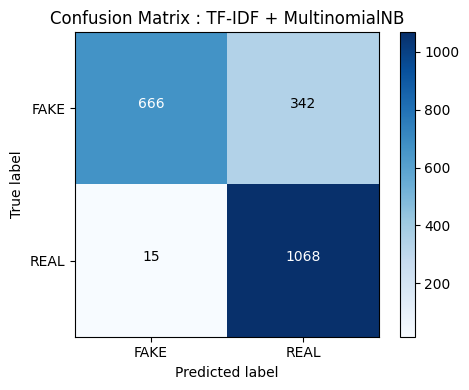

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

labels = ['FAKE', 'REAL']
tick_marks = np.arange(len(labels))
ax.set_xticks(tick_marks); ax.set_xticklabels(labels)
ax.set_yticks(tick_marks); ax.set_yticklabels(labels)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j],
            horizontalalignment='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title('Confusion Matrix : TF-IDF + MultinomialNB')
plt.tight_layout()
plt.show()

## 8. Predict a Single Article

In [17]:
# Inspect the raw text of the first article
print(dataset["text"][0])

Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. 
The word “unprecedented” has been thrown around so often this election that it ought to be retired. But it’s still unprecedented for the nominee of a major political party to go war with the FBI. 
But that’s exactly what Hillary and her people have done. Coma patients just waking up now and watching an hour of CNN from their hospital beds would assume that FBI Director James Comey is Hillary’s opponent in this election. 
The FBI is under attack by everyone from Obama to CNN. Hillary’s people have circulated a letter attacking Comey. There are currently more media hit pieces lambasting him than targeting Trump. It wouldn’t be too surprising if the Clintons or their allies were to start running attack ads against the FBI. 
The FBI’s leadership is being warned that the entire left

In [18]:
# View its TF-IDF representation (sparse)
print(tfidf_train[[0]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (1, 56922)>


In [19]:
# Predict the label for the first training article
print("Predicted label:", clf.predict(tfidf_train[[0]]))

Predicted label: ['FAKE']


In [20]:
# Predict on a completely new, custom sentence
new_article = ["Scientists confirm climate change is accelerating due to greenhouse gases."]
new_tfidf = tfidf_vectorizer.transform(new_article)   # use .transform(), NOT .fit_transform()
print("Custom input prediction:", clf.predict(new_tfidf))

Custom input prediction: ['REAL']


## 9. CountVectorizer vs TF-IDF : Side-by-Side Comparison

Run both vectorizers and compare accuracy to see which performs better on this dataset.

In [22]:
# --- CountVectorizer baseline (from original notebook) ---
count_vectorizer = CountVectorizer(stop_words='english')
count_train = count_vectorizer.fit_transform(X_train)
count_test  = count_vectorizer.transform(X_test)

clf_count = MultinomialNB()
clf_count.fit(count_train, y_train)
count_acc = metrics.accuracy_score(y_test, clf_count.predict(count_test))

# --- TF-IDF (already trained above) ---
tfidf_acc = score

print(f"CountVectorizer   + MultinomialNB -> accuracy: {count_acc:.3f}")
print(f"TF-IDF Vectorizer + MultinomialNB -> accuracy: {tfidf_acc:.3f}")

diff = tfidf_acc - count_acc

if diff > 0:
    winner = f"TF-IDF is better by {abs(diff):.3f}"
elif diff < 0:
    winner = f"CountVectorizer is better by {abs(diff):.3f}"
else:
    winner = "Both are equal"

print(f"\nDifference: {diff:+.3f}  --> {winner}")

CountVectorizer   + MultinomialNB -> accuracy: 0.893
TF-IDF Vectorizer + MultinomialNB -> accuracy: 0.829

Difference: -0.064  --> CountVectorizer is better by 0.064
